# Problem Statement

Task 1:-Prepare a complete data analysis report on the given data.

Task 2:- Explore football skills and cluster football players based on their attributes.

Task3:- Explore the data and attempt all the below asked questions in a
step by step manner:
     
     ● Prepare a rank ordered list of top 10 countries with most players. Which countries are producing the most footballers that play at this level?

     ● Plot the distribution of overall rating vs. age of players. Interpret what is the age after which a player stops improving?
     
     ● Which type of offensive players tends to get paid the most: the striker, the right-winger, or the left-winger?


# importing libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Google drive mount

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Fifa20 project/players_20.csv')


# Basic Checks

In [ ]:
df.head()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,...,66+3,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3


In [ ]:
print("number of rows:", df.shape[0])

number of rows: 18278


In [ ]:
print("number of columns:", df.shape[1])

number of columns: 104


In [ ]:
print("information of dataset:",df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18278 entries, 0 to 18277
Columns: 104 entries, sofifa_id to rb
dtypes: float64(16), int64(45), object(43)
memory usage: 14.5+ MB
information of dataset: None


In [ ]:
print("printing the columns:",df.columns)

printing the columns: Index(['sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob',
       'height_cm', 'weight_kg', 'nationality', 'club',
       ...
       'lwb', 'ldm', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb'],
      dtype='object', length=104)


In [ ]:
print("Statistical summary of numerical columns:")
df.describe()

Statistical summary of numerical columns:


,sofifa_id,age,height_cm,weight_kg,overall,potential,value_eur,wage_eur,international_reputation,weak_foot,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
count,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,1.827800e+04,18278.000000,18278.000000,18278.000000,...,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000
mean,219738.864482,25.283291,181.362184,75.276343,66.244994,71.546887,2.484038e+06,9456.942773,1.103184,2.944250,...,48.383357,58.528778,46.848889,47.640333,45.606631,16.572765,16.354853,16.212934,16.368038,16.709924
std,27960.200461,4.656964,6.756961,7.047744,6.949953,6.139669,5.585481e+06,21351.714095,0.378861,0.664656,...,15.708099,11.880840,20.091287,21.585641,21.217734,17.738069,16.996925,16.613665,17.136497,18.038125
min,768.000000,16.000000,156.000000,50.000000,48.000000,49.000000,0.000000e+00,0.000000,1.000000,1.000000,...,7.000000,12.000000,1.000000,5.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,204445.500000,22.000000,177.000000,70.000000,62.000000,67.000000,3.250000e+05,1000.000000,1.000000,3.000000,...,39.000000,51.000000,29.000000,27.000000,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,226165.000000,25.000000,181.000000,75.000000,66.000000,71.000000,7.000000e+05,3000.000000,1.000000,3.000000,...,49.000000,60.000000,52.000000,55.000000,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,240795.750000,29.000000,186.000000,80.000000,71.000000,75.000000,2.100000e+06,8000.000000,1.000000,3.000000,...,60.000000,67.000000,64.000000,66.000000,64.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,252905.000000,42.000000,205.000000,110.000000,94.000000,95.000000,1.055000e+08,565000.000000,5.000000,5.000000,...,92.000000,96.000000,94.000000,92.000000,90.000000,90.000000,92.000000,93.000000,91.000000,92.000000


In [ ]:
print("Statistical summary of categorical columns:")
df.describe(include='object')

Statistical summary of categorical columns:


,player_url,short_name,long_name,dob,nationality,club,player_positions,preferred_foot,work_rate,body_type,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
count,18278,18278,18278,18278,18278,18278,18278,18278,18278,18278,...,16242,16242,16242,16242,16242,16242,16242,16242,16242,16242
unique,18278,17354,18218,6142,162,698,643,2,9,10,...,98,98,98,98,98,96,110,110,110,96
top,https://sofifa.com/player/233449/ximing-pan/20...,J. Rodríguez,Liam Kelly,1992-02-29,England,Wolverhampton Wanderers,CB,Right,Medium/Medium,Normal,...,59+2,59+2,59+2,59+2,59+2,61+2,63+2,63+2,63+2,61+2
freq,1,11,3,113,1667,33,2322,13960,9875,10750,...,682,636,636,636,682,667,621,621,621,667


In [ ]:
print("null values:")
df.isnull().sum()

null values:


,0
sofifa_id,0
player_url,0
short_name,0
long_name,0
age,0
...,...
lb,2036
lcb,2036
cb,2036
rcb,2036


It clearly shows that dataset has null values.

In [ ]:
print("unique values:")
df.nunique()

unique values:


,0
sofifa_id,18278
player_url,18278
short_name,17354
long_name,18218
age,27
...,...
lb,96
lcb,110
cb,110
rcb,110


In [ ]:
print("Duplicate values:")
df.duplicated().sum()

Duplicate values:


np.int64(0)

dataset has 0 deuplicate values

In [ ]:
df.drop('player_url',inplace=True,axis=1)

In [ ]:
df.head()

,sofifa_id,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,overall,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,94,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,93,...,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,92,...,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,91,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,91,...,66+3,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3


In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

print("Numerical Columns:", len(num_cols))
print("Categorical columns:",len(cat_cols))

Numerical Columns: 61
Categorical columns: 42


# Exploratory Data Analysis

# Univariate Analysis

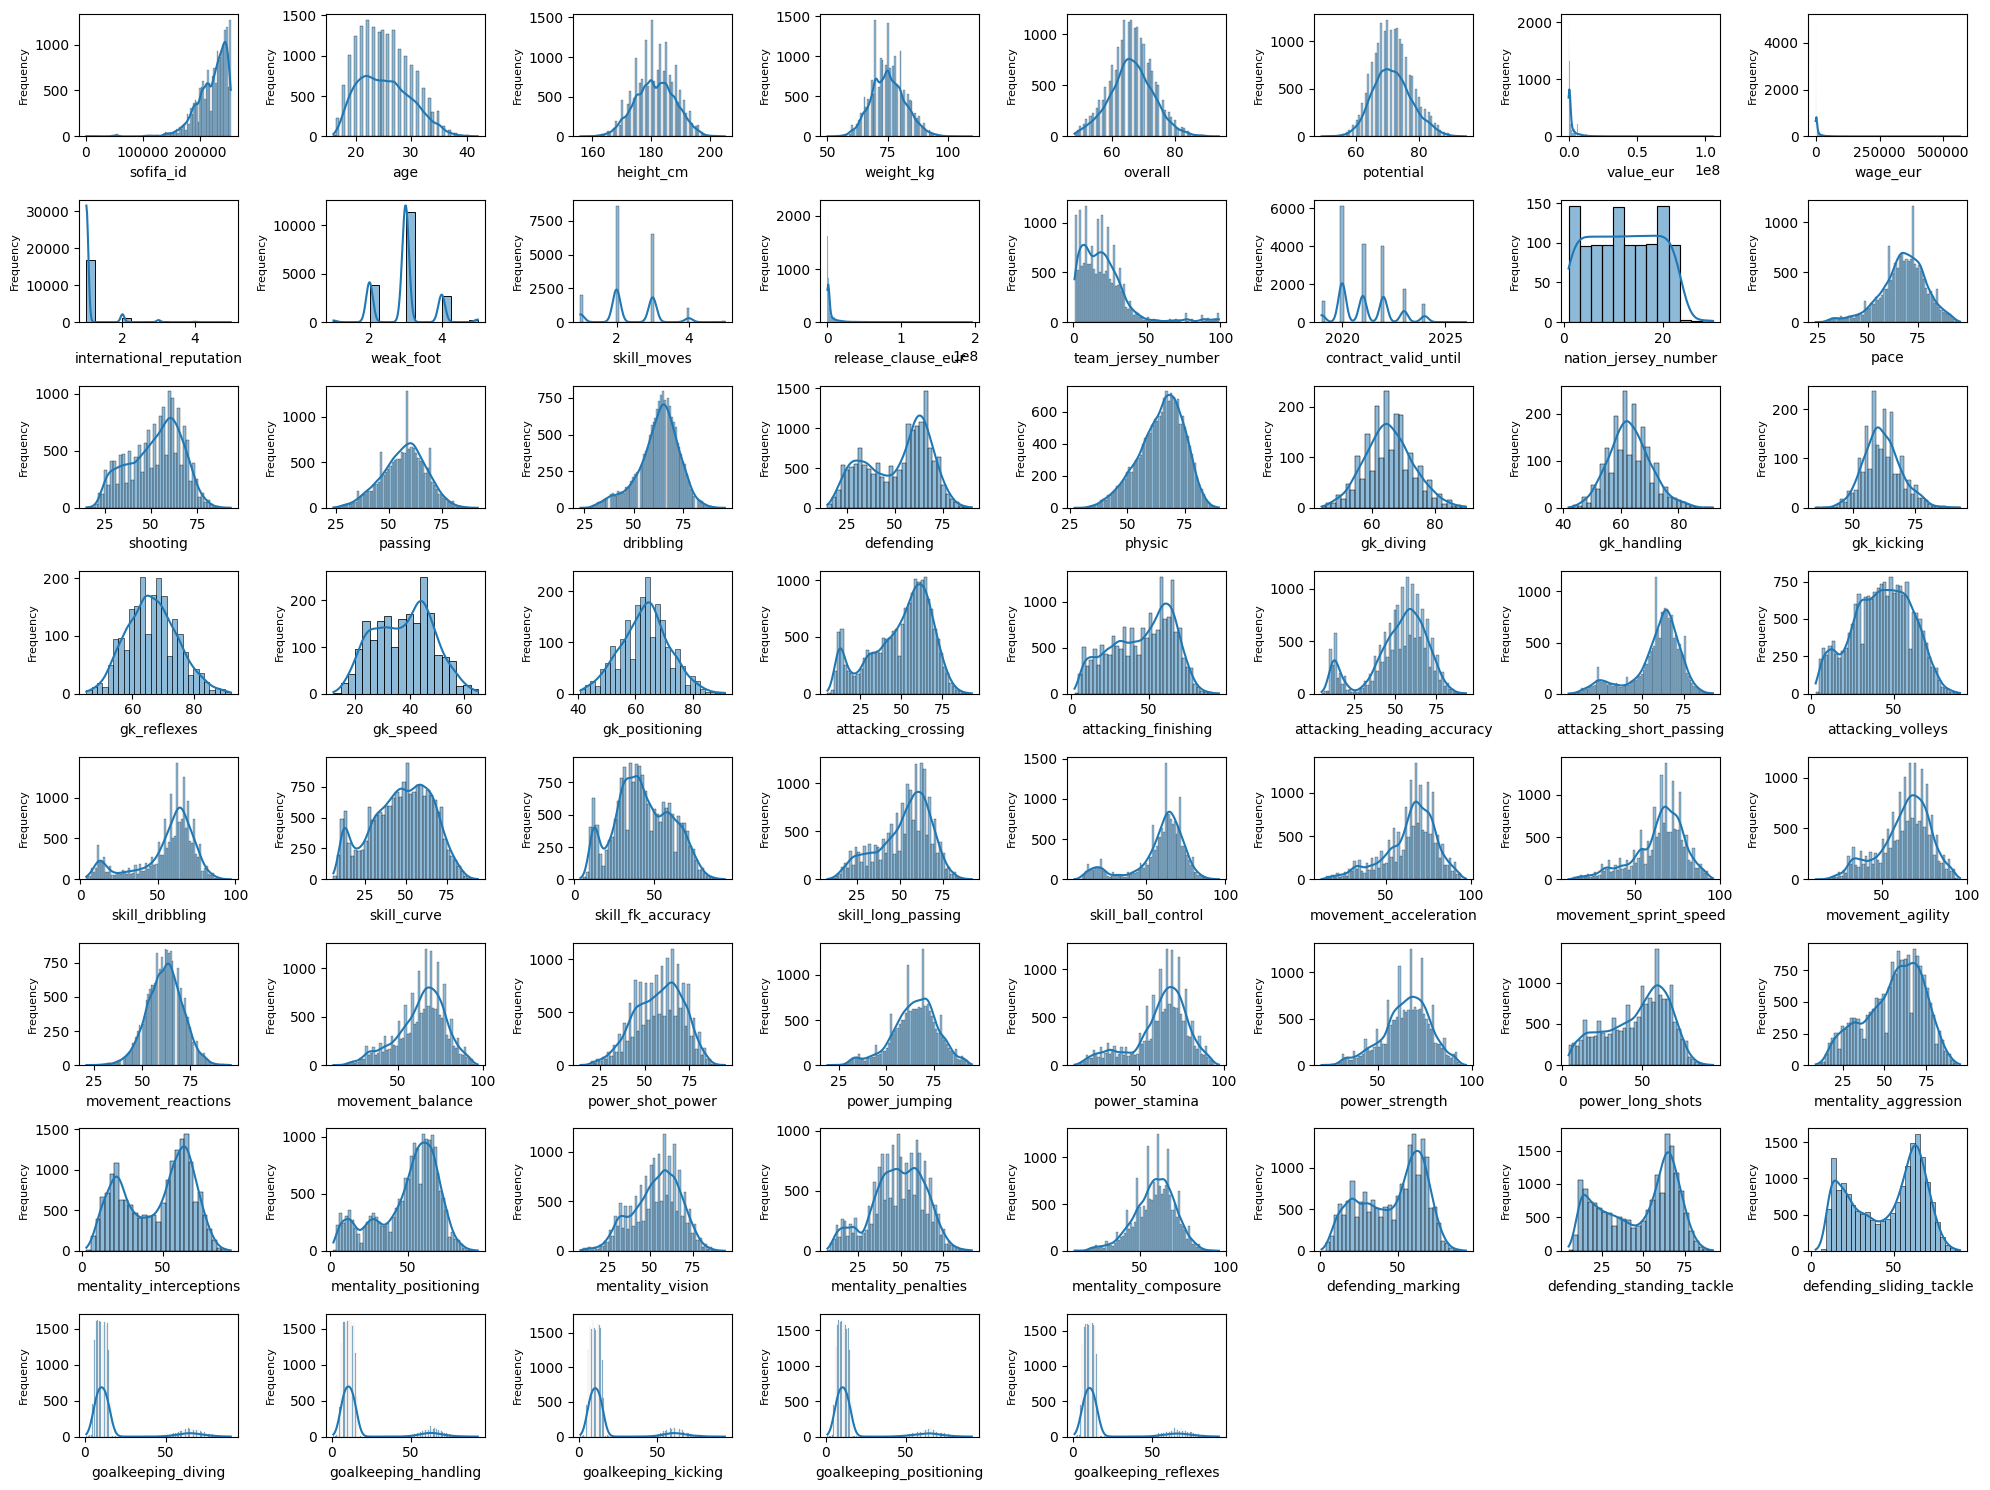

In [ ]:
plt.figure(figsize=(20, 15),facecolor='white')
plotnumber=1

for col in num_cols:
  if plotnumber<=len(num_cols):
    ax=plt.subplot(8,8,plotnumber)
    sns.histplot(df[col],kde=True)
    plt.xlabel(col,fontsize=10)
    plt.ylabel('Frequency',fontsize=8)
  plotnumber+=1
plt.tight_layout()
plt.show()

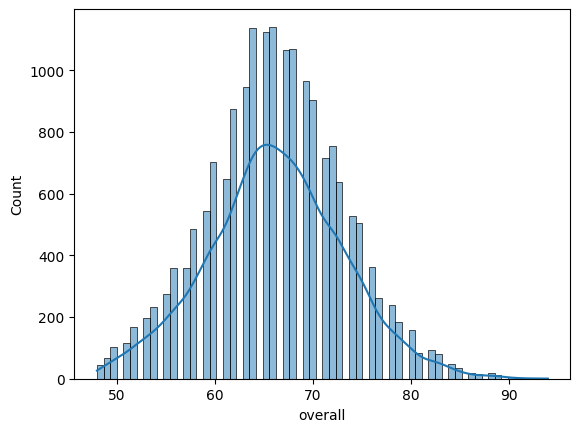

In [ ]:
sns.histplot(data=df ,x='overall' , kde=True)
plt.show()

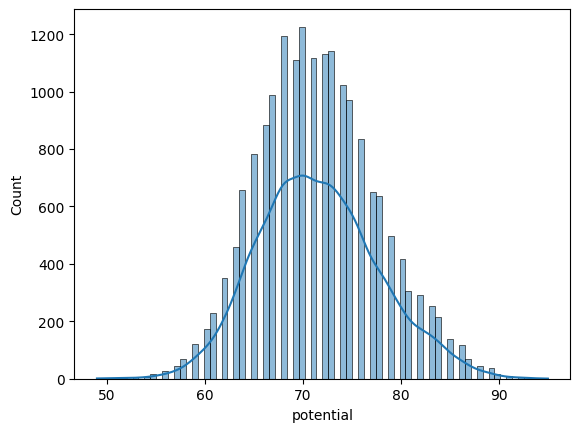

In [ ]:
sns.histplot(data=df ,x='potential' , kde=True)
plt.show()

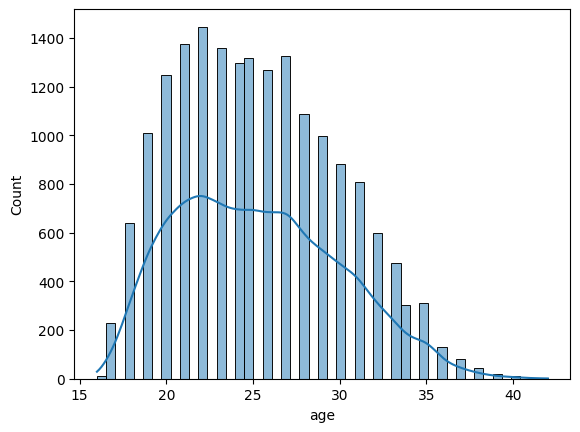

In [ ]:
sns.histplot(data=df ,x='age' , kde=True)
plt.show()

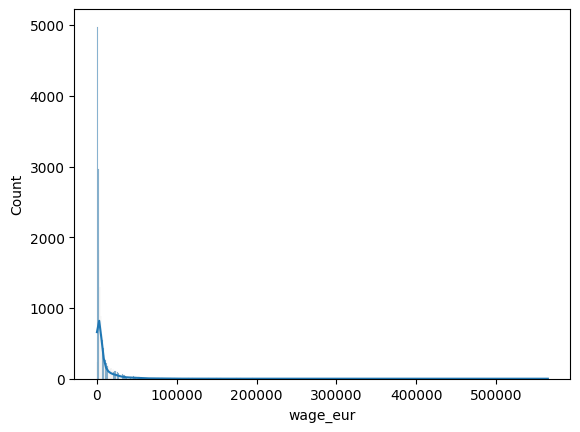

In [ ]:
sns.histplot(data=df ,x='wage_eur' , kde=True)
plt.show()

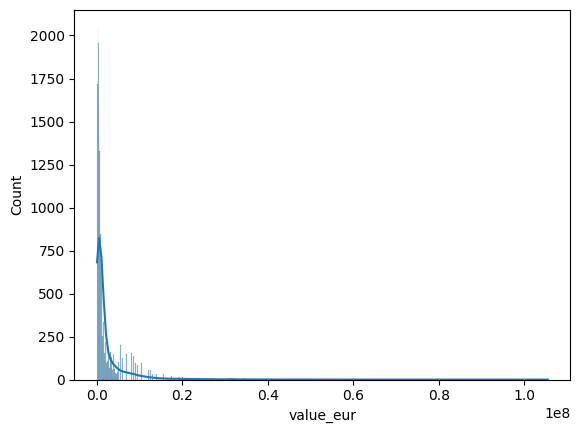

In [ ]:
sns.histplot(data=df ,x='value_eur' , kde=True)
plt.show()

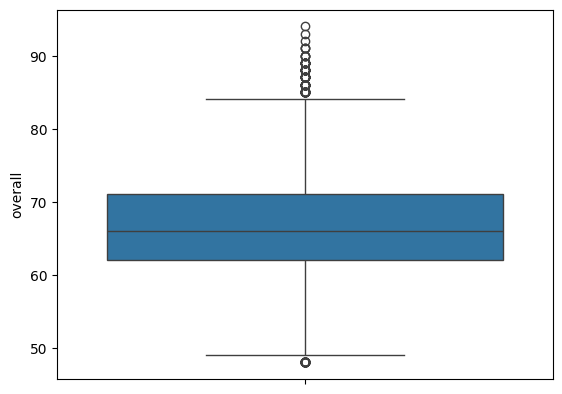

In [ ]:
sns.boxplot(data=df ,y='overall')
plt.show()

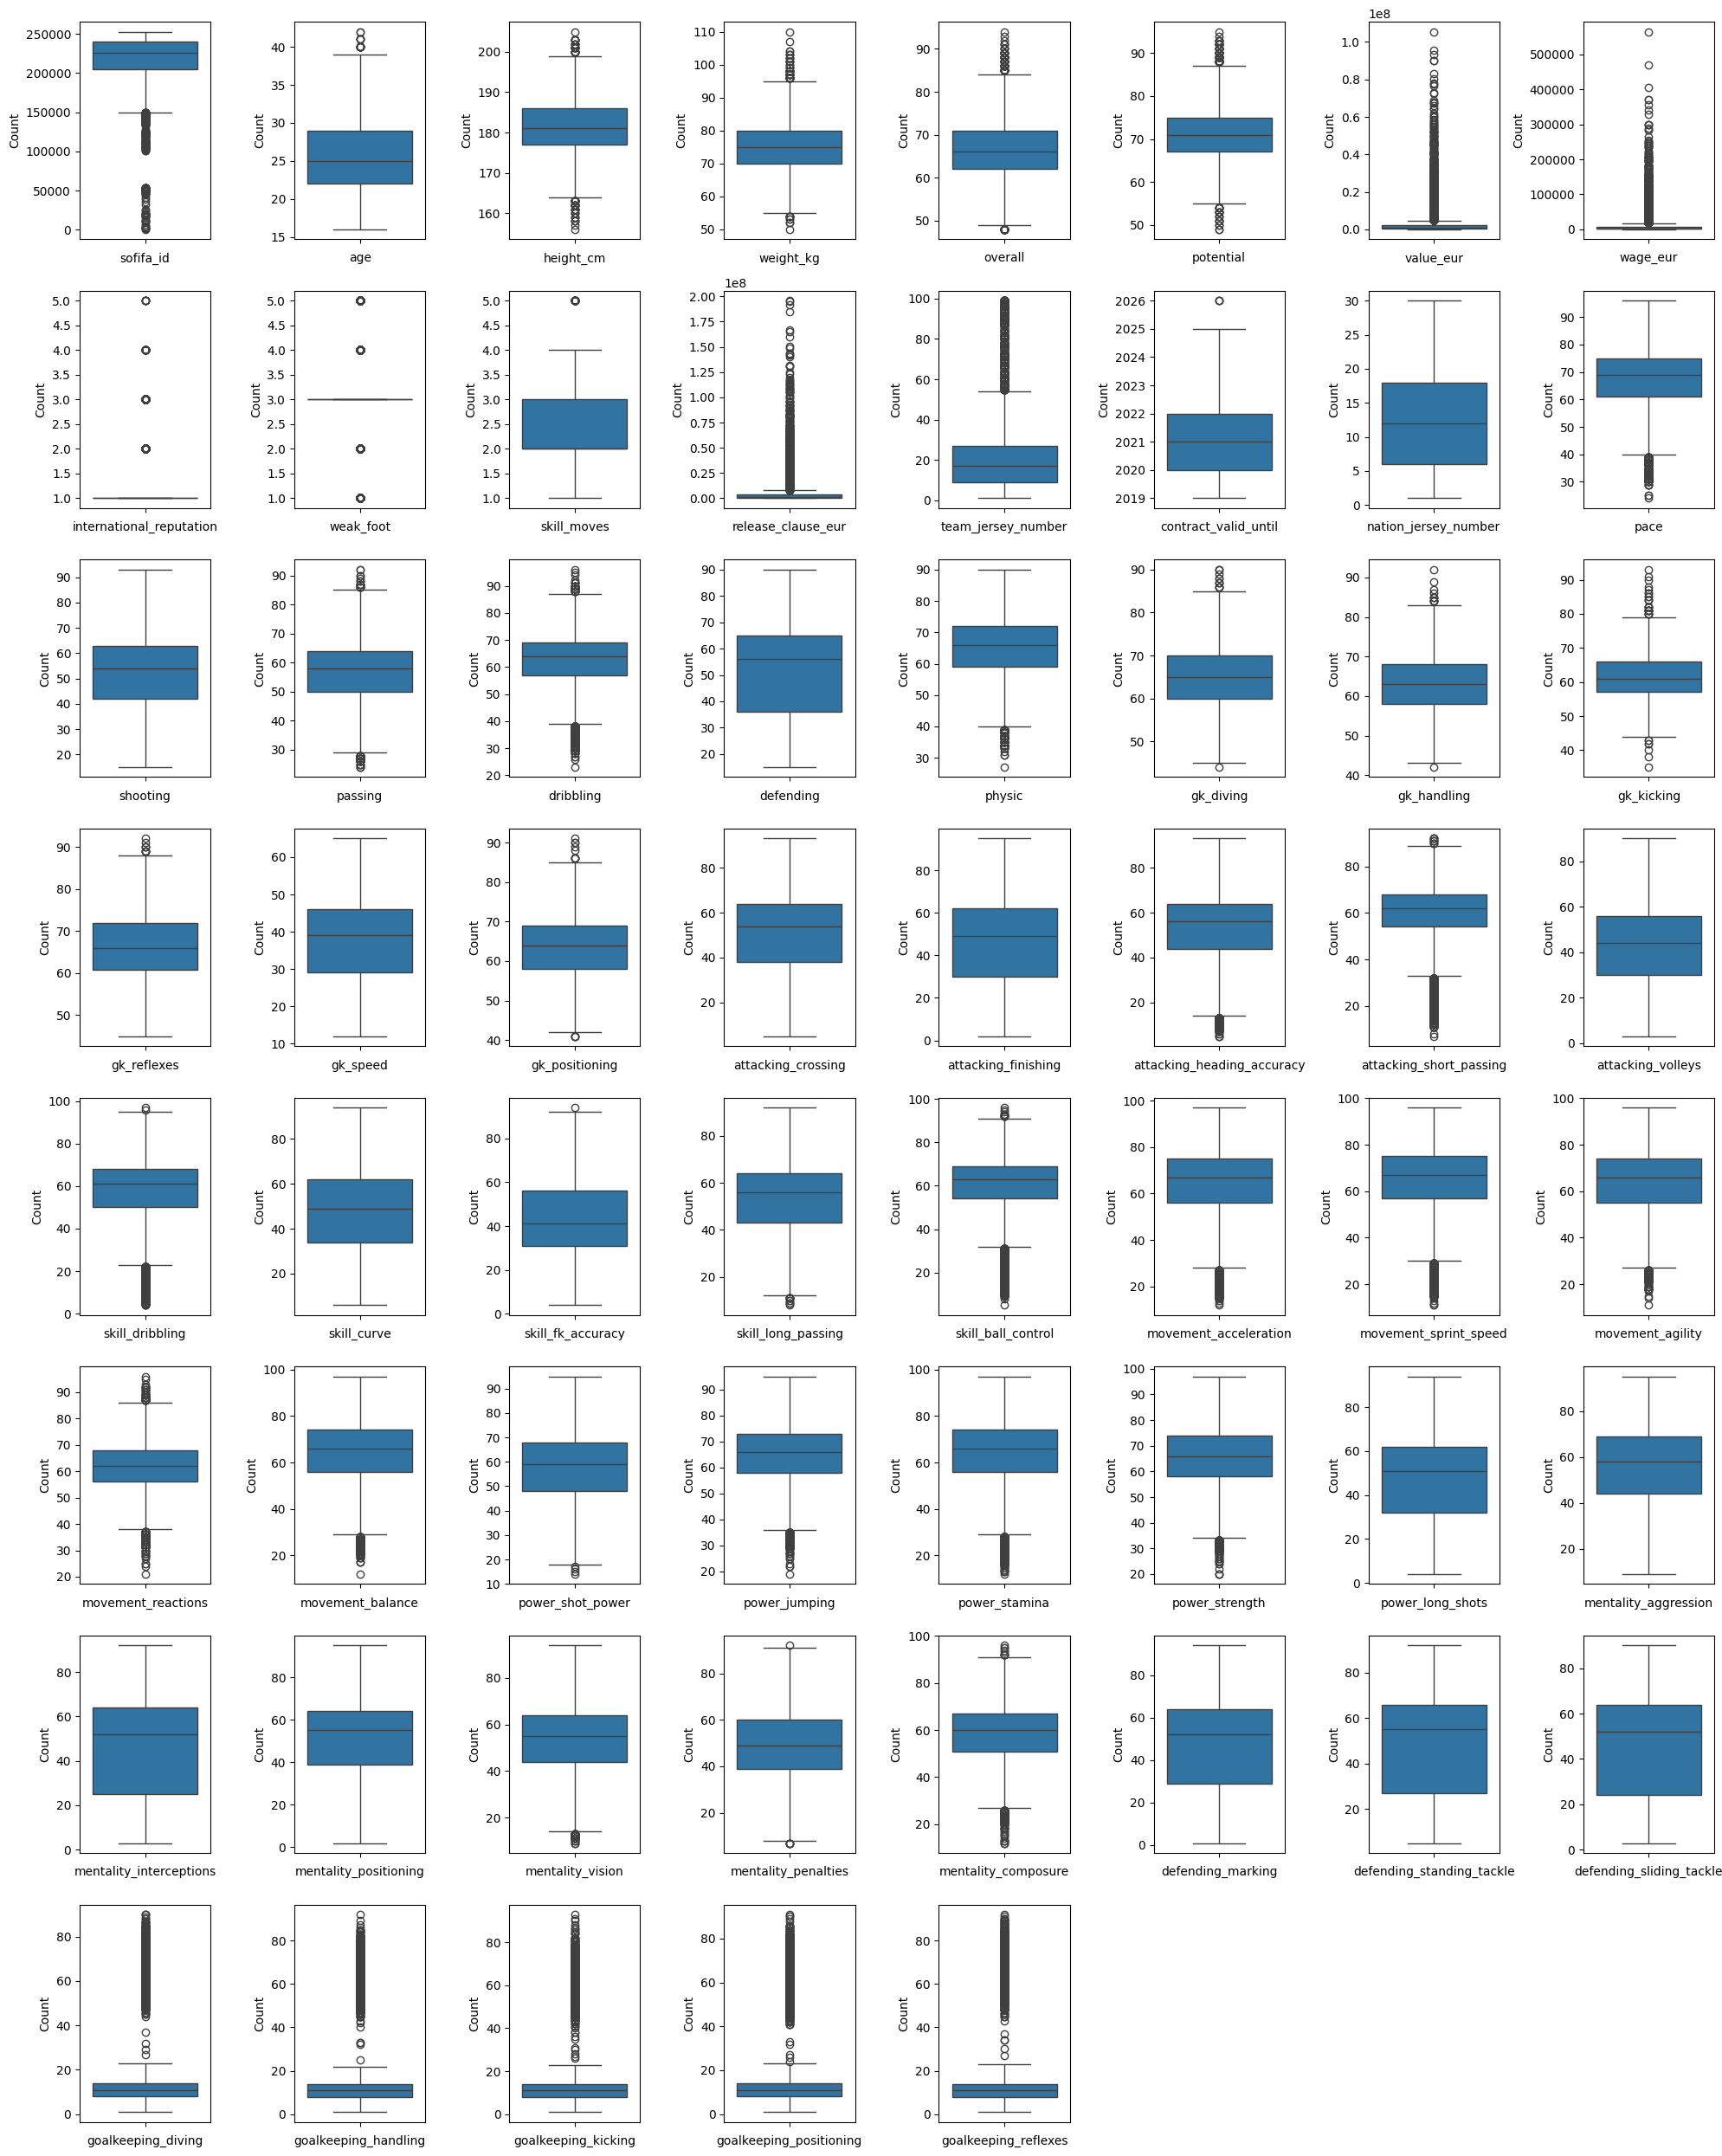

In [ ]:
plt.figure(figsize=(20,25),facecolor='white')
plotnumber=1

for column in num_cols:
    if plotnumber<=61:
        ax=plt.subplot(8,8,plotnumber)
        sns.boxplot(df[column])
        plt.xlabel(column,fontsize=10)
        plt.ylabel('Count',fontsize=10)
    plotnumber+=1
plt.tight_layout()

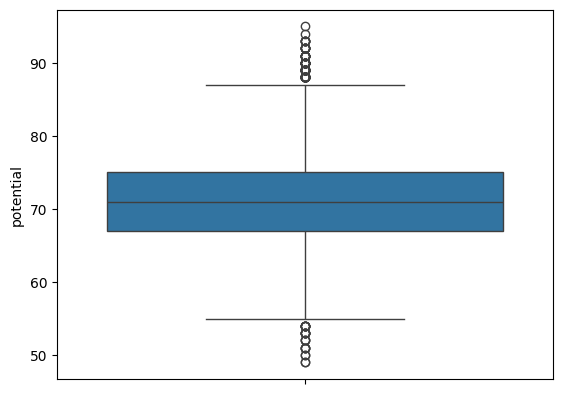

In [ ]:
sns.boxplot(data=df ,y='potential')
plt.show()

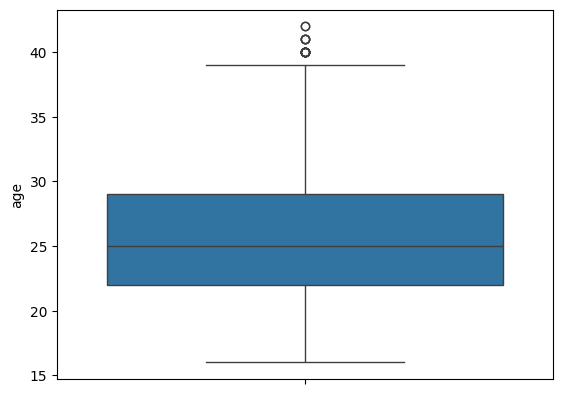

In [ ]:
sns.boxplot(data=df ,y='age')
plt.show()

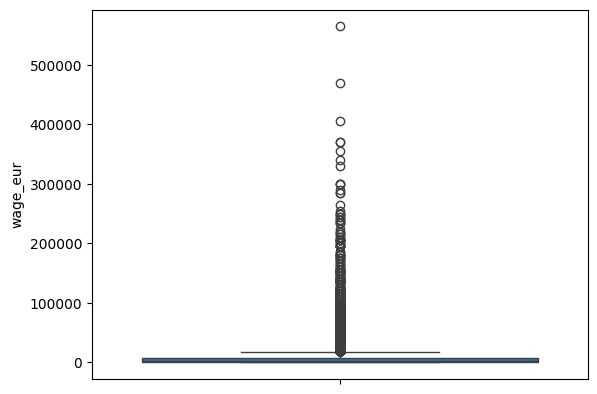

In [ ]:
sns.boxplot(data=df ,y='wage_eur')
plt.show()

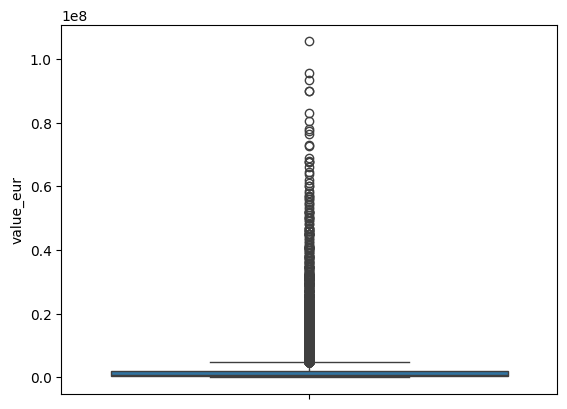

In [ ]:
sns.boxplot(data=df ,y='value_eur')
plt.show()

#Biavariate Analysis

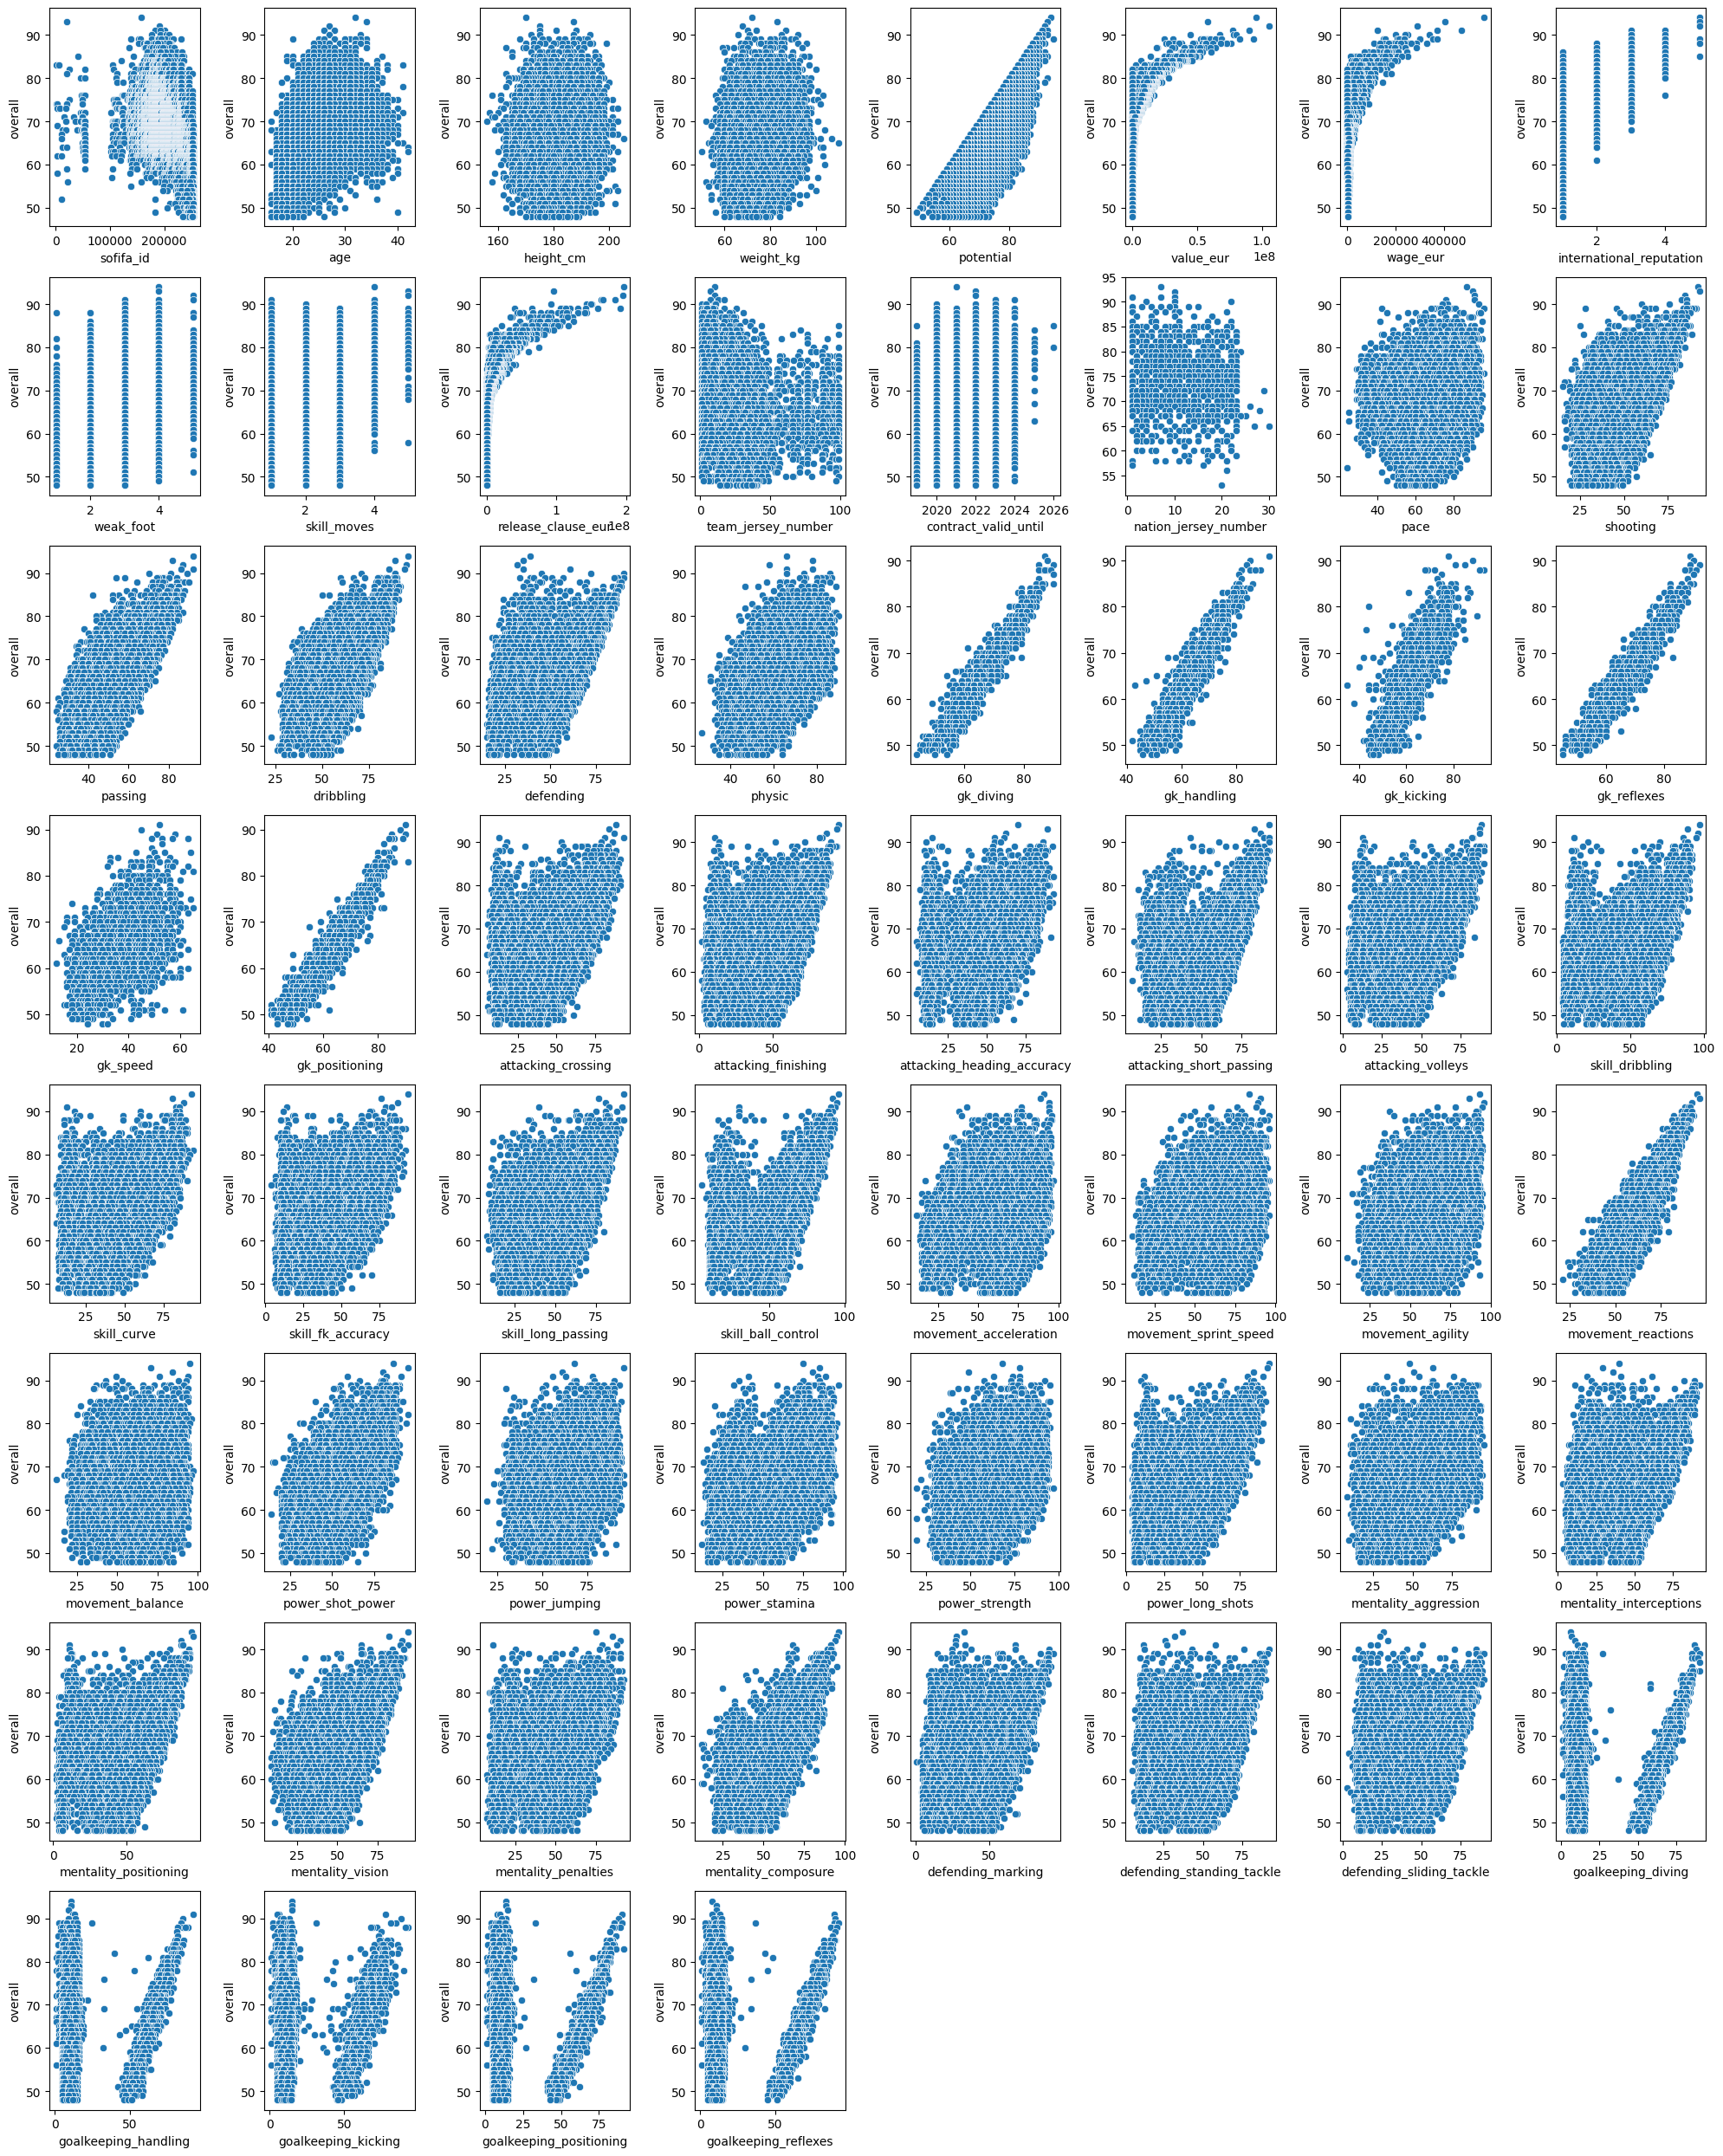

In [ ]:
plt.figure(figsize=(20, 25), facecolor='white')
plotnumber = 1

# Exclude the target column from features
features = [col for col in num_cols if col != 'overall']

for column in features:
    if plotnumber <= 61:
        ax = plt.subplot(8, 8, plotnumber)
        sns.scatterplot(x=df[column], y=df['overall'])
        plt.xlabel(column, fontsize=10)
        plt.ylabel('overall', fontsize=10)
    plotnumber += 1

plt.tight_layout()

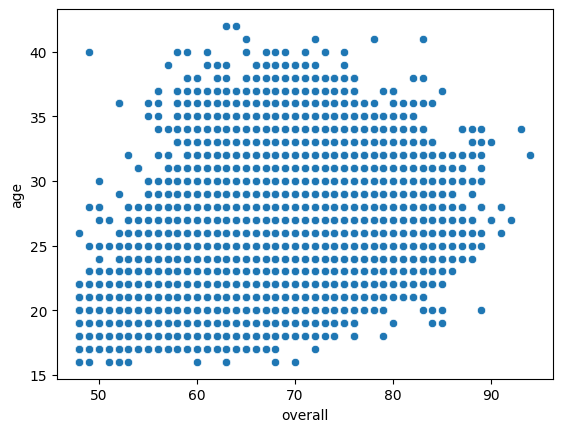

In [ ]:
sns.scatterplot(data=df ,x='overall' , y='age')
plt.show()

From this gargh we can assume that players from agea ~22-30 has highest overall rating upto 70-80.

As the age increase from 30 , overall rating decrease .

It showing positive correlation between 'age' and 'overall'

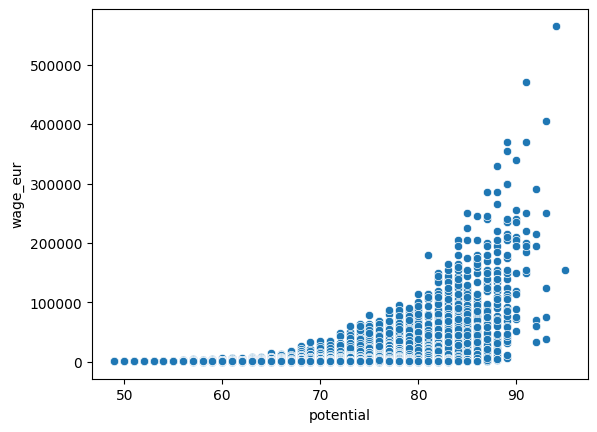

In [ ]:
sns.scatterplot(data=df , x='potential', y='wage_eur')
plt.show()

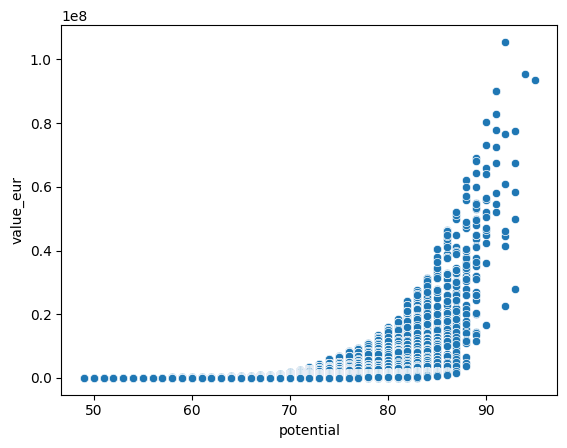

In [ ]:
sns.scatterplot(data=df , x='potential', y='value_eur')
plt.show()

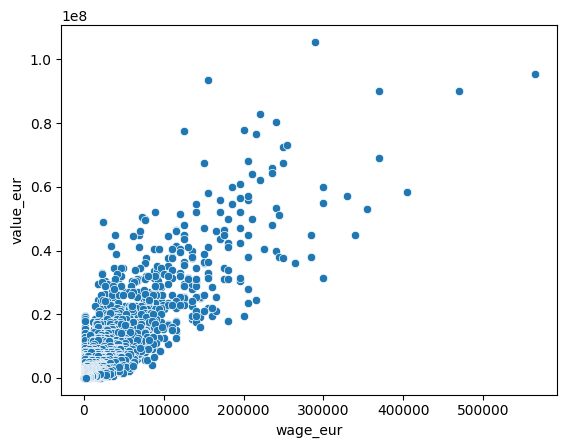

In [ ]:
sns.scatterplot(data=df,x='wage_eur',y='value_eur')
plt.show()

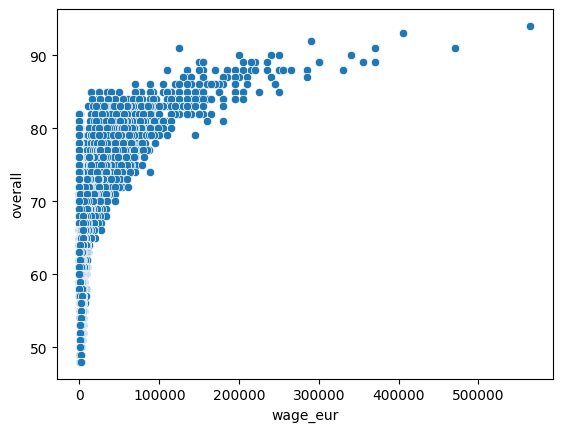

In [ ]:
sns.scatterplot(data=df,x='wage_eur',y='overall')
plt.show()

These 3 graphs are not showing as positive correlation .

# correlation matrix heatmap

In [ ]:
numerical_df = df[num_cols]
correlation_matrix = numerical_df.corr()


In [ ]:
correlation_matrix

,sofifa_id,age,height_cm,weight_kg,overall,potential,value_eur,wage_eur,international_reputation,weak_foot,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
sofifa_id,1.000000,-0.736680,-0.093464,-0.203620,-0.445061,0.042015,-0.159848,-0.228084,-0.360765,-0.092250,...,-0.147125,-0.385061,-0.131479,-0.087414,-0.068464,-0.113073,-0.116270,-0.114658,-0.123064,-0.113487
age,-0.736680,1.000000,0.081391,0.237169,0.464305,-0.262872,0.081513,0.151031,0.259582,0.073988,...,0.141375,0.370149,0.157007,0.116857,0.101534,0.110313,0.112929,0.112615,0.121381,0.111811
height_cm,-0.093464,0.081391,1.000000,0.768816,0.039945,-0.002432,0.009527,0.019547,0.037935,-0.175200,...,-0.335786,-0.159296,-0.077038,-0.068334,-0.076953,0.367433,0.367163,0.364992,0.367097,0.367375
weight_kg,-0.203620,0.237169,0.768816,1.000000,0.156522,-0.011738,0.051782,0.065946,0.090854,-0.128568,...,-0.246309,-0.054167,-0.049683,-0.052770,-0.064492,0.342329,0.343211,0.339805,0.344397,0.343126
overall,-0.445061,0.464305,0.039945,0.156522,1.000000,0.646650,0.638230,0.573578,0.475557,0.230276,...,0.347950,0.719992,0.303075,0.249891,0.219560,-0.013239,-0.013716,-0.017393,-0.006408,-0.012775
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
goalkeeping_diving,-0.113073,0.110313,0.367433,0.342329,-0.013239,-0.049662,-0.022094,-0.023629,0.006039,-0.232714,...,-0.624495,-0.414361,-0.544390,-0.533440,-0.512461,1.000000,0.971330,0.967057,0.971218,0.973922
goalkeeping_handling,-0.116270,0.112929,0.367163,0.343211,-0.013716,-0.050859,-0.022119,-0.023590,0.005962,-0.232357,...,-0.623164,-0.413082,-0.545373,-0.534141,-0.513340,0.971330,1.000000,0.966508,0.970517,0.971244
goalkeeping_kicking,-0.114658,0.112615,0.364992,0.339805,-0.017393,-0.056216,-0.023048,-0.024679,0.004454,-0.228380,...,-0.619899,-0.411327,-0.542991,-0.533623,-0.512314,0.967057,0.966508,1.000000,0.966061,0.967866
goalkeeping_positioning,-0.123064,0.121381,0.367097,0.344397,-0.006408,-0.049007,-0.020554,-0.022428,0.008561,-0.230529,...,-0.621893,-0.406664,-0.540967,-0.530873,-0.509761,0.971218,0.970517,0.966061,1.000000,0.971060


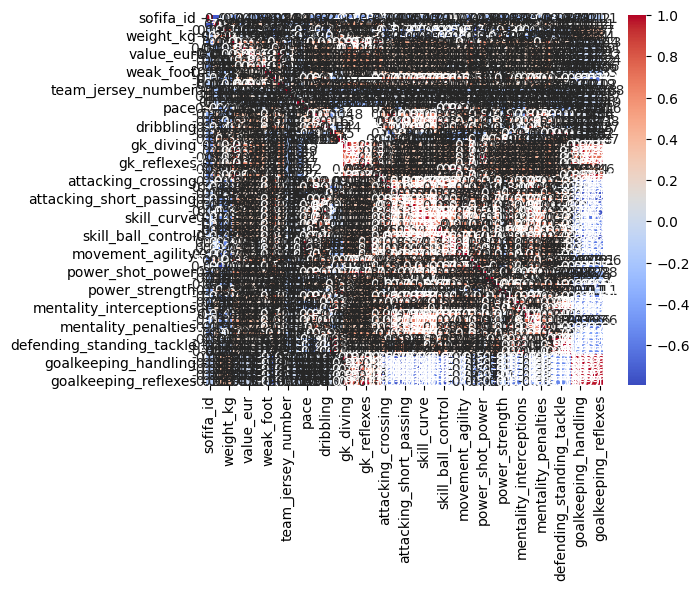

In [ ]:
sns.heatmap(correlation_matrix, annot=True , cmap='coolwarm')
plt.show()

In [ ]:
df.columns

Index(['sofifa_id', 'short_name', 'long_name', 'age', 'dob', 'height_cm',
       'weight_kg', 'nationality', 'club', 'overall',
       ...
       'lwb', 'ldm', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb'],
      dtype='object', length=103)

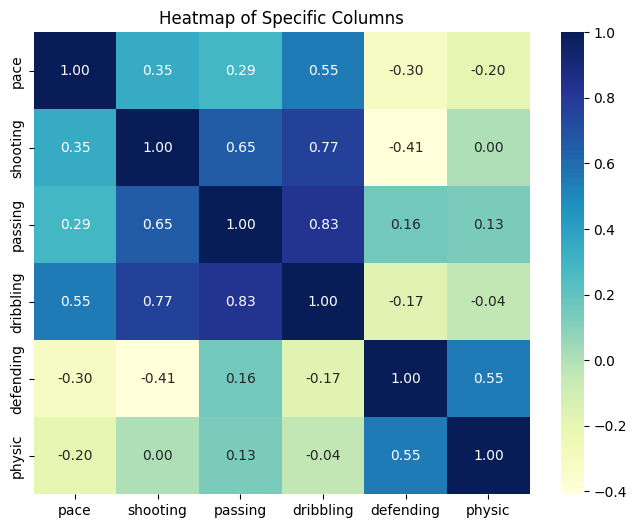

In [ ]:
# Use the original df DataFrame to select the columns for the heatmap
columns_to_plot =['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
subset_df = df[columns_to_plot]

plt.figure(figsize=(8, 6))
sns.heatmap(subset_df.corr(), annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Heatmap of Specific Columns')
plt.show()

 ● Prepare a rank ordered list of top 10 countries with most players. Which countries are producing the most footballers that play at this level?

 ● Plot the distribution of overall rating vs. age of players. Interpret what is the age after which a player stops improving?

 ● Which type of offensive players tends to get paid the most: the striker, the right-winger, or the left-winger?


In [ ]:
# list of top 10 countries that are producing the most footballers.
df.nationality.value_counts().head(10)

,count
nationality,
England,1667
Germany,1216
Spain,1035
France,984
Argentina,886
Brazil,824
Italy,732
Colombia,591
Japan,453


In [ ]:
# Filter for players whose primary or secondary positions are 'ST', 'LW', or 'RW'
offensive_positions = ['ST', 'LW', 'RW']
filtered_df = df[df['player_positions'].str.contains('|'.join(offensive_positions))]


# Extract the primary position for plotting (assuming the first position listed is primary)
# This is a simplification, a player can have multiple positions
filtered_df['primary_offensive_position'] = filtered_df['player_positions'].apply(lambda x: x.split(', ')[0] if x.split(', ')[0] in ['ST', 'LW', 'RW'] else 'Other Offensive')

# Filter out 'Other Offensive' if we only want to compare ST, LW, RW
offensive_players_for_plot = filtered_df[filtered_df['primary_offensive_position'].isin(['ST', 'LW', 'RW'])].copy()

/tmp/ipython-input-1779870490.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['primary_offensive_position'] = filtered_df['player_positions'].apply(lambda x: x.split(', ')[0] if x.split(', ')[0] in ['ST', 'LW', 'RW'] else 'Other Offensive')


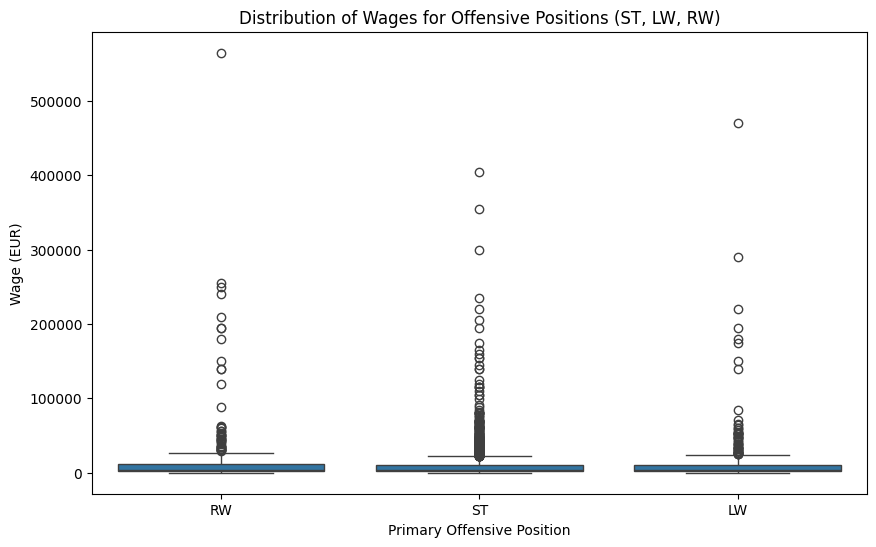

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=offensive_players_for_plot, x='primary_offensive_position', y='wage_eur')
plt.title('Distribution of Wages for Offensive Positions (ST, LW, RW)')
plt.xlabel('Primary Offensive Position')
plt.ylabel('Wage (EUR)')
plt.show()

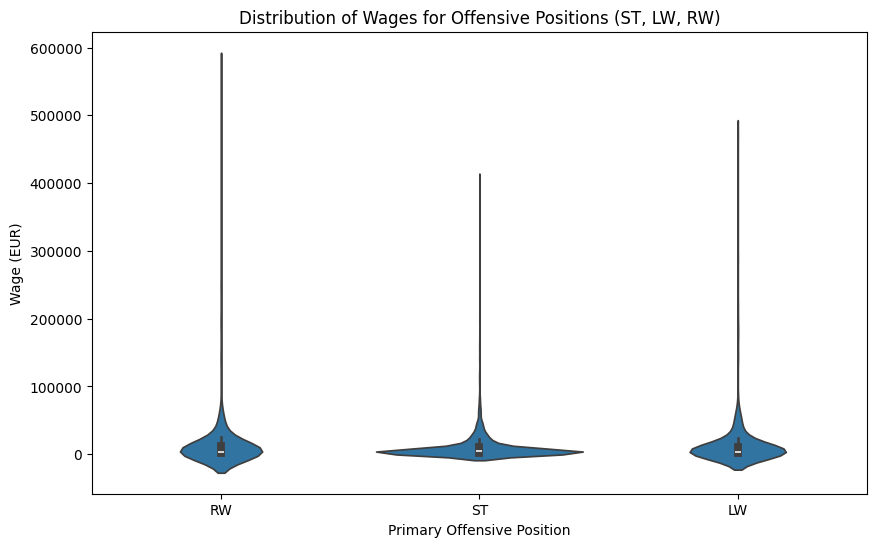

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=offensive_players_for_plot, x='primary_offensive_position', y='wage_eur')
plt.title('Distribution of Wages for Offensive Positions (ST, LW, RW)')
plt.xlabel('Primary Offensive Position')
plt.ylabel('Wage (EUR)')
plt.show()

from this plot we can say that wages for offensive positions is  heavily skewed .

ST has more dispersion than RW and LW.

all offensive position has outliers .
